# Setting

## Import packages

In [1]:
# === System & Utility ===
import os
import glob
import re
import time
import json
import math
import itertools
from dotenv import load_dotenv
import requests

# === Data Handling ===
import pandas as pd
import numpy as np
import geopandas as gpd

# === Geospatial & Location ===
import osmnx as ox
from shapely.geometry import Point
from shapely.wkt import dumps, loads
from geopy.geocoders import Nominatim

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# === Statistical Tools ===
from scipy import stats
from scipy.stats import norm, chi2_contingency, pointbiserialr

# === Preprocessing & Dimensionality Reduction ===
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# === Evaluation Metrics ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, make_scorer, roc_auc_score
)

# === Classification Models ===
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# === Regression Models ===
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# === Display Settings ===
pd.set_option('display.precision', 4)

## Self-defined functions

### check_table_info

In [3]:
def check_table_info(target_df):
    """
    To check the unique values, dtype, example, missing rate of each column
    """
    table_info = []
    for col in target_df:
        table_info_row = []
        table_info_row.append(col)
        table_info_row.append(target_df[col].nunique())
        table_info_row.append(target_df[col].dtype)
        table_info_row.append(target_df[col].iloc[0])
        table_info_row.append(round(target_df[col].isna().sum() / target_df.shape[0]*100,2))

        table_info.append(table_info_row)
    res = pd.DataFrame(table_info, columns=['col_name', 'unique_values', 'dtype', 'example', 'missing%'])

    return res

### load_geoDataFrame

In [4]:
def load_geoDataFrame(filepath):
    """
    Load a GeoDataFrame from a CSV file with a geometry column in WKT format.

    Parameters:
        filepath (str): Path to the CSV file containing the saved GeoDataFrame.

    Returns:
        GeoDataFrame: A GeoDataFrame reconstructed from the CSV, with geometries parsed from WKT strings.
    
    Notes:
        - Assumes the geometry column is named 'geometry' and stored in WKT format.
        - The returned GeoDataFrame is assigned the CRS 'EPSG:4326' by default.
    """
    df = pd.read_csv(filepath)
    df['geometry'] = df['geometry'].apply(loads)
    return gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

### gen_point_area_buffer_mapping

In [5]:
def gen_point_area_buffer_mapping(point_df, lat_col, lon_col, grid_df, grid_id_col='grid_id', buffer_radius_m=1000):
    """
    Maps each point in point_df to a nearby grid cell (from grid_df) using a centroid-based buffer.

    Parameters:
        point_df (pd.DataFrame): DataFrame with point locations, must include latitude and longitude columns.
        lat_col (str): Name of the latitude column in point_df.
        lon_col (str): Name of the longitude column in point_df.
        grid_df (gpd.GeoDataFrame): GeoDataFrame with polygon grid geometries (e.g., Manhattan grid).
        grid_id_col (str): Column in grid_df representing the unique ID of each grid (default: 'grid_id').
        buffer_radius_m (float): Radius in meters to buffer around each grid's centroid (default: 1000 meters).

    Returns:
        gpd.GeoDataFrame: A GeoDataFrame with all points that fall within any grid centroid's buffer,
                          including matched grid IDs.
    """
    # Project grid to a suitable projected CRS (NYC local)
    grid_proj = grid_df.to_crs(epsg=2263)
    grid_proj['centroid'] = grid_proj.geometry.centroid
    grid_proj['buffer'] = grid_proj['centroid'].buffer(buffer_radius_m)

    # Create buffer GeoDataFrame
    buffer_gdf = grid_proj[[grid_id_col, 'buffer']].copy()
    buffer_gdf = buffer_gdf.set_geometry('buffer')
    buffer_gdf = buffer_gdf.set_crs(epsg=2263)

    # Prepare point GeoDataFrame and project to same CRS
    point_df = point_df.dropna(subset=[lat_col, lon_col]).copy()
    point_gdf = gpd.GeoDataFrame(
        point_df,
        geometry=gpd.points_from_xy(point_df[lon_col], point_df[lat_col]),
        crs="EPSG:4326"
    )
    point_proj = point_gdf.to_crs(epsg=2263)

    # Drop potential naming conflict column
    if 'index_right' in point_proj.columns:
        point_proj = point_proj.drop(columns=['index_right'])

    # Spatial join: points within buffer zones
    joined = gpd.sjoin(point_proj, buffer_gdf, how='inner', predicate='within')

    return joined

### calculate_trips_by_buffer

In [6]:
def calculate_trips_by_buffer(
    df, 
    grid_df, 
    prefix,
    lat_col='lat', 
    lon_col='lon', 
    trip_time_col='trip_time', 
    trips_col='trips', 
    grid_id_col='grid_id', 
    buffer_distances=[500, 900, 1200], 
    buffer_labels=['core', 'secondary', 'edge']
):
    """
    General function to calculate trips (bike, subway, etc.) within multiple buffer zones around grids.

    Parameters:
        df (pd.DataFrame): DataFrame containing trip data.
        grid_df (pd.DataFrame): DataFrame containing grid geometry and grid IDs.
        lat_col (str): Latitude column name.
        lon_col (str): Longitude column name.
        trip_time_col (str): Trip time column name.
        trips_col (str): Trips column name.
        grid_id_col (str): Grid ID column name.
        prefix (str): The prefix for output column names (e.g., 'bike', 'subway').
        buffer_distances (list): List of buffer distances in meters.
        buffer_labels (list): Corresponding labels for buffer zones (same order as distances).
        point_area_func (function): Function to calculate buffer mapping (your existing spatial function).

    Returns:
        pd.DataFrame: Merged DataFrame with trips per zone and time.
    """
    assert len(buffer_distances) == len(buffer_labels), "buffer_distances and buffer_labels must be the same length."
    
    prefix = prefix.strip().lower()
    station_points = df[[lat_col, lon_col]].drop_duplicates()

    buffer_dfs = {}
    for dist, label in zip(buffer_distances, buffer_labels):
        buffer_df = gen_point_area_buffer_mapping(
            point_df=station_points,
            lat_col=lat_col,
            lon_col=lon_col,
            grid_df=grid_df[[grid_id_col, 'geometry']],
            grid_id_col=grid_id_col,
            buffer_radius_m=dist
        )
        buffer_dfs[label] = buffer_df

    # Group trips for each zone
    merged = None
    for label in buffer_labels:
        buffer_df = buffer_dfs[label]
        tmp = df.merge(buffer_df[[lat_col, lon_col, grid_id_col]], on=[lat_col, lon_col])
        tmp_grouped = tmp.groupby([trip_time_col, grid_id_col])[trips_col].sum().reset_index()
        tmp_grouped = tmp_grouped.rename(columns={trips_col: f'{prefix}_trips_{label}_zone_cumulative'})
        
        if merged is None:
            merged = tmp_grouped
        else:
            merged = merged.merge(tmp_grouped, on=[trip_time_col, grid_id_col], how='outer').fillna(0)
    
    # Extract date and hour
    merged['date'] = pd.to_datetime(pd.to_datetime(merged[trip_time_col]).dt.date)
    merged['hour'] = pd.to_datetime(merged[trip_time_col]).dt.hour.astype(int)
    
    # Calculate exclusive trips within each zone (non-overlapping rings)
    cumulative_cols = [f'{prefix}_trips_{label}_zone_cumulative' for label in buffer_labels]
    merged[f'{prefix}_trips_{buffer_labels[-1]}_zone'] = merged[cumulative_cols[-1]] - merged[cumulative_cols[-2]]
    merged[f'{prefix}_trips_{buffer_labels[1]}_zone'] = merged[cumulative_cols[1]] - merged[cumulative_cols[0]]
    merged[f'{prefix}_trips_{buffer_labels[0]}_zone'] = merged[cumulative_cols[0]]
    
    # Final column selection
    final_cols = ['date', 'hour', grid_id_col] + \
                 [f'{prefix}_trips_{label}_zone' for label in buffer_labels]
    
    return merged[final_cols]

### convert_percentile_to_level

In [7]:
def convert_percentile_to_level(series):
    """
    Convert continuous percentile values to 5-level categorical bins
    (equal-width binning from min to max).
    """
    min_val = series.min()
    max_val = series.max()
    bins = np.linspace(min_val, max_val, 6)  # 5 bins
    labels = ['1', '2', '3', '4', '5']

    result = pd.cut(
        series,
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    return result

### plot_busyness_percentile_map

In [8]:
def plot_busyness_percentile_map(df, date_str, hour_int, busyness_level, ax=None, figsize=(6, 6), cmap='OrRd'):
    # 1. Filter data for the specified date and hour
    df_hour = df[(df['date'] == date_str) & (df['hour'] == hour_int)].copy()

    # 2. Convert to GeoDataFrame and reproject to Web Mercator
    gdf = gpd.GeoDataFrame(df_hour, geometry='geometry', crs='EPSG:4326').to_crs(epsg=3857)

    # 3. Drop rows with missing percentile values
    gdf = gdf.dropna(subset=[busyness_level])

    # 4. Prepare ax
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # 5. Plot the heatmap
    gdf.plot(
        ax=ax,
        column=busyness_level,
        cmap=cmap,
        linewidth=0.1,
        edgecolor='white',
        legend=True,
        legend_kwds={'title': busyness_level, 'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'}
    )

    ax.set_title(f"{busyness_level} - {date_str} {hour_int:02d}:00", fontsize=12)
    ax.axis("off")


### classification_evaluation

In [9]:
def classification_evaluation(y_actual, y_pred):
    """
    Prints a full evaluation report for multiclass classification results.

    Shows:
    - Accuracy
    - Precision (macro)
    - Recall (macro)
    - F1 score (macro)
    - Confusion matrix
    - Classification report

    Args:
        y_actual (array-like): True class labels
        y_pred (array-like): Predicted class labels
    """

    print("Accuracy       :", round(accuracy_score(y_actual, y_pred), 3))
    print("Precision Score:", round(precision_score(y_actual, y_pred, average='macro'), 3))
    print("Recall Score   :", round(recall_score(y_actual, y_pred, average='macro'), 3))
    print("F1 Score       :", round(f1_score(y_actual, y_pred, average='macro'), 3))
    print()

    # Confusion Matrix
    cm = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_actual, y_pred, zero_division=1))

### predict_sample_dataset

In [10]:
def predict_sample_dataset(model, input_X, input_y, 
                           sample_size=1000000, 
                           y_type='categorical', 
                           is_lgbm=False, is_cat=False,
                           eval_metric=None):
    """
    Train and evaluate a model on a sampled dataset.

    Parameters:
        model: sklearn, LightGBM, or CatBoost model
        input_X (DataFrame): feature set
        input_y (Series): target
        sample_size (int): max sample size
        y_type (str): 'continuous' or 'categorical'
        is_lgbm (bool): use LGBM-style training
        is_cat (bool): use CatBoost-style training
        eval_metric (str): metric for model evaluation
    """

    if y_type not in ['continuous', 'categorical']:
        raise ValueError('y_type must be "continuous" or "categorical"')

    # Sample
    X_sample = input_X.sample(n=min(sample_size, len(input_X)), random_state=42)
    y_sample = input_y.loc[X_sample.index]

    # Split
    stratify_arg = y_sample if y_type == 'categorical' else None
    X_train, X_test, y_train, y_test = train_test_split(
        X_sample, y_sample, test_size=0.3, stratify=stratify_arg, random_state=42
    )

    cat_features = X_sample.select_dtypes('category').columns.tolist()

    # Fit
    if not is_lgbm and not is_cat:
        model.fit(X_train, y_train)
    elif is_lgbm:
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            eval_metric=eval_metric,
            categorical_feature=cat_features,
            callbacks=[lgb.early_stopping(10)]
        )
    elif is_cat:
        model.fit(
            X_train, y_train,
            eval_set=(X_test, y_test),
            cat_features=cat_features)

    # Predict
    y_pred = model.predict(X_test)

    # Optional fix for CatBoost regression/classification float output
    if is_cat and y_type == 'categorical' and not np.issubdtype(y_pred.dtype, np.integer):
        y_pred = np.round(y_pred).astype(int)

    # Evaluate
    if y_type == 'continuous':
        y_test_label = convert_percentile_to_level(pd.Series(y_test).reset_index(drop=True))
        y_pred_label = convert_percentile_to_level(pd.Series(y_pred).reset_index(drop=True))
    else:
        y_test_label = y_test
        y_pred_label = y_pred

    classification_evaluation(y_test_label, y_pred_label)

### encode_features

In [11]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

def encode_features(input_df, input_features, drop_first=True):
    """
    Transforms input features for modeling:
    
    - Boolean features are converted to integers (0 or 1).
    - Categorical features (dtype 'category') are one-hot encoded.
        - Optionally drops the first dummy column to avoid multicollinearity.
    - Numerical (continuous) features are standardized using StandardScaler.
    
    Tracks:
    - The original-to-transformed column mappings.
    - Which dummy columns (baseline categories) were dropped.

    Args:
        input_df (pd.DataFrame): Original input DataFrame.
        input_features (list): List of column names to transform.
        drop_first (bool): Whether to drop the first dummy variable for each categorical feature.

    Returns:
        encoded_df (pd.DataFrame): Final encoded DataFrame ready for modeling.
        drop_col_df (pd.DataFrame): Info about dropped dummy columns (if any).
        mapping_df (pd.DataFrame): Mapping from original features to encoded columns.
    """
    encoded_df = pd.DataFrame(index=input_df.index)
    drop_col_records = []
    mapping_records = []

    for feature in input_features:
        series = input_df[feature]

        if series.dtype.name == 'bool':
            # Convert boolean to integer (0/1)
            encoded_df[feature] = series.astype(int)
            mapping_records.append({'original_feature': feature, 'feature': feature})

        elif series.dtype.name == 'category':
            # One-hot encode categorical
            dummies = pd.get_dummies(series, prefix=feature, prefix_sep='_', drop_first=False)

            for dummy_col in dummies.columns:
                mapping_records.append({'original_feature': feature, 'feature': dummy_col})

            if drop_first:
                dropped_col = dummies.columns[0]
                drop_col_records.append({
                    'original_feature': feature,
                    'baseline_category': dropped_col,
                    'true_cases': dummies[dropped_col].sum()
                })
                dummies.drop(columns=[dropped_col], inplace=True)

            encoded_df = pd.concat([encoded_df, dummies], axis=1)

        else:
            # Standardize numeric feature
            scaler = StandardScaler()
            standardized = scaler.fit_transform(series.values.reshape(-1, 1))
            encoded_df[feature] = standardized.flatten()
            mapping_records.append({'original_feature': feature, 'feature': feature})

    drop_col_df = pd.DataFrame(drop_col_records)
    mapping_df = pd.DataFrame(mapping_records)

    return encoded_df, drop_col_df, mapping_df

# Load DataFrame

In [2]:
new_buffer_df = pd.read_pickle('new_combined_all_df.pkl')
new_buffer_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 9986400 entries, 0 to 9986399
Data columns (total 26 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   date                         datetime64[ns]
 1   hour                         category      
 2   temp_c                       float64       
 3   dew_c                        float64       
 4   wind_speed_knot              float64       
 5   precip_mm                    float64       
 6   grid_id                      category      
 7   lat                          float64       
 8   lon                          float64       
 9   geometry                     geometry      
 10  restaurant_count             float64       
 11  taxi_passenger_count         float64       
 12  event_count                  float64       
 13  population                   float64       
 14  is_holiday                   category      
 15  bike_trips_core_zone         float64     

# Compute Busyness percentiles using zscore_weighted_percentile
Since we have already compared different methods for generating the busyness score in `03_final_score_refinement_and_model_evaluation.ipynb`, and found that `busyness_zscore_weighted_percentile` consistently outperforms the others. Therefore, we will continue to use this method to examine whether the newly adjusted buffer components can also produce reasonable spatial patterns on the heatmap and maintain strong performance in the model.

## Weight Selection and Justification

Five weighting strategies were considered to reflect different assumptions about how transportation modes and spatial zones contribute to potential restaurant demand within urban areas. While all schemes incorporate the principle of spatial decay (closer trips have more impact) and acknowledge differences between transportation modes, the relative emphasis varies as follows:

**1. weights_1 (Balanced Baseline):**
- All modes and zones are weighted relatively evenly. Taxi has moderate weight as a proxy for external demand.
- Balanced across subway, bike, and taxi.

**2. weights_2 (Tourist / Night-Time Bias):**
- Taxi receives the highest weight, assuming night-time, tourism, and non-local demand are the key drivers.
- Taxi dominant.

**3.weights_3 (Local Life Bias)**
- Neighborhood activity and local commuting dominate. Bike and subway (core zones) are given more weight.
- Subway + bike core zones prioritized.

**4. weights_4 (Transit Bias)**
- Public transit is considered the strongest factor in driving busyness, especially around core subway areas.
- Subway > Taxi > Bike.

**5. weights_5 (Walkability / Neighborhood Bias)**
- Neighborhood liveliness through biking and walking dominates. Taxi plays only a minor role.
- Bike dominant.

In [19]:
# Balanced across subway, bike, and taxi
weights_1 = {
    'subway_trips_core_zone': 0.15,
    'subway_trips_secondary_zone': 0.1,
    'subway_trips_edge_zone': 0.05, 
    'bike_trips_core_zone': 0.2,
    'bike_trips_secondary_zone': 0.15,
    'bike_trips_edge_zone': 0.05,
    'taxi_passenger_count': 0.3
}

# Taxi dominant
weights_2 = {
    'subway_trips_core_zone': 0.1,
    'subway_trips_secondary_zone': 0.05,
    'subway_trips_edge_zone': 0.02,
    'bike_trips_core_zone': 0.2,
    'bike_trips_secondary_zone': 0.1,
    'bike_trips_edge_zone': 0.03,
    'taxi_passenger_count': 0.5
}

# Subway + bike core zones prioritized.
weights_3 = {
    'subway_trips_core_zone': 0.2,
    'subway_trips_secondary_zone': 0.1,
    'subway_trips_edge_zone': 0.05,
    'bike_trips_core_zone': 0.25,
    'bike_trips_secondary_zone': 0.2,
    'bike_trips_edge_zone': 0.05,
    'taxi_passenger_count': 0.15
}

# Subway > Taxi > Bike.
weights_4 = {
    'subway_trips_core_zone': 0.25,
    'subway_trips_secondary_zone': 0.15,
    'subway_trips_edge_zone': 0.05,
    'bike_trips_core_zone': 0.15,
    'bike_trips_secondary_zone': 0.05,
    'bike_trips_edge_zone': 0.05,
    'taxi_passenger_count': 0.3
}

# Bike dominant
weights_5 = {
    'subway_trips_core_zone': 0.1,
    'subway_trips_secondary_zone': 0.05,
    'subway_trips_edge_zone': 0.02,
    'bike_trips_core_zone': 0.3,
    'bike_trips_secondary_zone': 0.25,
    'bike_trips_edge_zone': 0.08,
    'taxi_passenger_count': 0.2
}

traffic_cols = [
    'subway_trips_core_zone', 'subway_trips_secondary_zone', 'subway_trips_edge_zone',
    'bike_trips_core_zone', 'bike_trips_secondary_zone', 'bike_trips_edge_zone',    
    'taxi_passenger_count'
]

weight1_array = np.array([weights_1[col] for col in traffic_cols])
weight2_array = np.array([weights_2[col] for col in traffic_cols])
weight3_array = np.array([weights_3[col] for col in traffic_cols])
weight4_array = np.array([weights_4[col] for col in traffic_cols])
weight5_array = np.array([weights_5[col] for col in traffic_cols])

weight_arrays = [weight1_array, weight2_array, weight3_array, weight4_array, weight5_array]

In [20]:
scaler = StandardScaler()
new_buffer_df[[f + '_z' for f in traffic_cols]] = scaler.fit_transform(new_buffer_df[traffic_cols])
busyness_percentile_cols = []

for i, weight_array in enumerate(weight_arrays, start=1):
    new_buffer_df[f'busyness_zscore_weighted_{i}'] = np.dot(
        new_buffer_df[[f + '_z' for f in traffic_cols]].values,
        weight_array
    )
    new_buffer_df[f'busyness_zscore_weighted_percentile_{i}'] = norm.cdf(
        new_buffer_df[f'busyness_zscore_weighted_{i}']
    )
    new_buffer_df[f'busyness_level_{i}'] = convert_percentile_to_level(
        new_buffer_df[f'busyness_zscore_weighted_percentile_{i}']
    )
    busyness_percentile_cols.append(f'busyness_level_{i}')
busyness_percentile_cols

['busyness_level_1',
 'busyness_level_2',
 'busyness_level_3',
 'busyness_level_4',
 'busyness_level_5']

## Compare on heatmap
- All of the five methods show quite reasonable spatial patterns

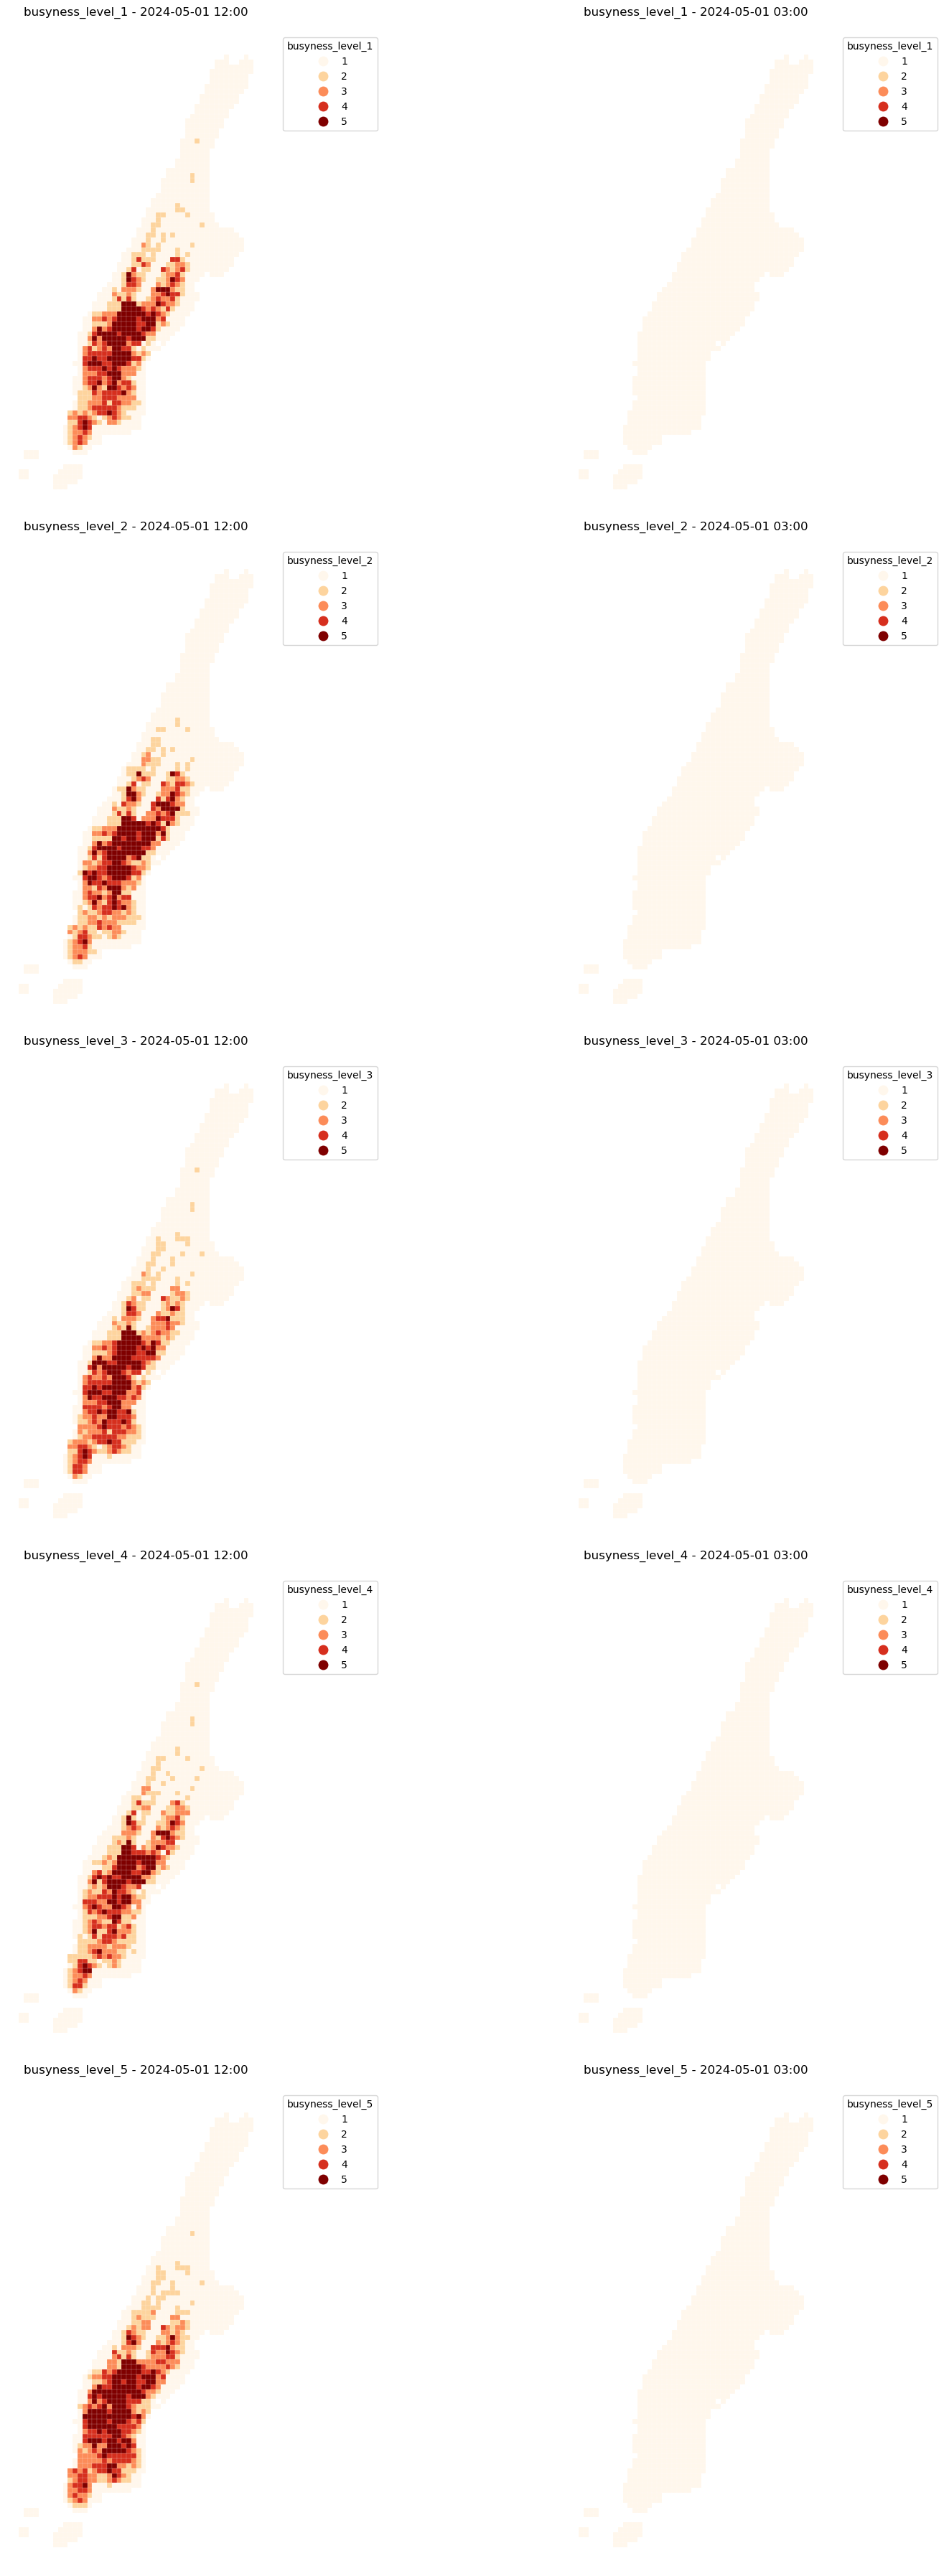

In [21]:
fig, axes = plt.subplots(5, 2, figsize=(18, 36))
i = 0
for col in busyness_percentile_cols:    
    plot_busyness_percentile_map(new_buffer_df, '2024-05-01', 12, col, ax=axes[i, 0])
    plot_busyness_percentile_map(new_buffer_df, '2024-05-01', 3, col, ax=axes[i, 1])
    i += 1

plt.tight_layout()
plt.show()

## Compare Model Performance using LightGBM
- All methods are used for evaluation on the sample dataset, as all of them produce reasonable spatial patterns on the heatmap.
- Performance on Sample Dataset
    - busyness_level_1
        - Accuracy       : 0.905
        - Precision Score: 0.779
        - Recall Score   : 0.775
        - F1 Score       : 0.777
    
    - busyness_level_2
        - Accuracy       : 0.909
        - Precision Score: 0.785
        - Recall Score   : 0.779
        - F1 Score       : 0.782
    
    - busyness_level_3
        - Accuracy       : 0.897
        - Precision Score: 0.759
        - Recall Score   : 0.753
        - F1 Score       : 0.756
    
    - busyness_level_4
        - Accuracy       : 0.92
        - Precision Score: 0.8
        - Recall Score   : 0.797
        - F1 Score       : 0.798
    
    - busyness_level_5
        - Accuracy       : 0.887
        - Precision Score: 0.744
        - Recall Score   : 0.738
        - F1 Score       : 0.741
- `busyness_level_4` is selected as a target variable because it achieves the best overall performance among the five compared methods.

In [19]:
X_lgbm = new_buffer_df[['month', 'weekofyear', 'dayofweek', 'is_weekend', 'day', 'hour', 'is_holiday', # time
                        'temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm', # weather
                        'grid_id', 'restaurant_count', 'population', # grid info
                        'lat', 'lon', # could be removed
                        'event_count', # event
                       ]]

In [24]:
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    learning_rate=0.1,
    num_leaves=64,
    n_estimators=100,
    random_state=42
)

===
busyness_level_1
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2145
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 17
[LightGBM] [Info] Start training from score -0.362377
[LightGBM] [Info] Start training from score -2.207769
[LightGBM] [Info] Start training from score -2.667025
[LightGBM] [Info] Start training from score -2.904065
[LightGBM] [Info] Start training from score -2.662469
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's

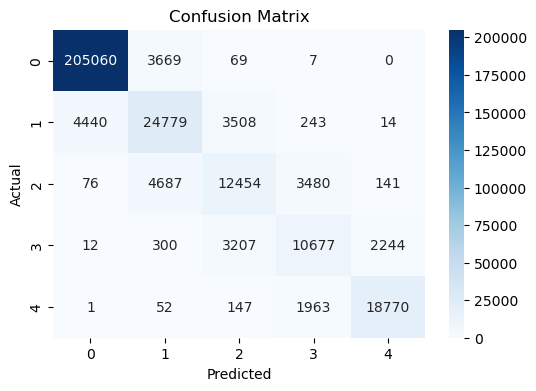


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    208805
           1       0.74      0.75      0.75     32984
           2       0.64      0.60      0.62     20838
           3       0.65      0.65      0.65     16440
           4       0.89      0.90      0.89     20933

    accuracy                           0.91    300000
   macro avg       0.78      0.78      0.78    300000
weighted avg       0.90      0.91      0.91    300000

===
busyness_level_2
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030425 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM

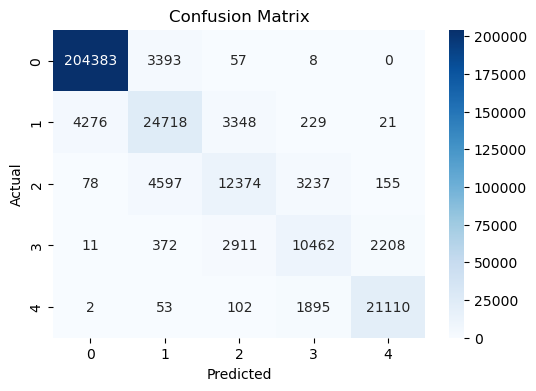


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    207841
           1       0.75      0.76      0.75     32592
           2       0.66      0.61      0.63     20441
           3       0.66      0.66      0.66     15964
           4       0.90      0.91      0.90     23162

    accuracy                           0.91    300000
   macro avg       0.79      0.78      0.79    300000
weighted avg       0.91      0.91      0.91    300000

===
busyness_level_3
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041489 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM

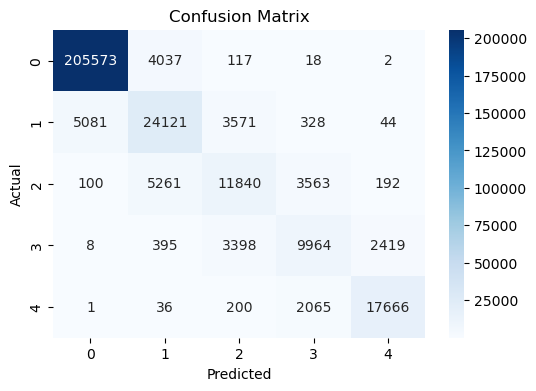


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    209747
           1       0.71      0.73      0.72     33145
           2       0.62      0.56      0.59     20956
           3       0.63      0.62      0.62     16184
           4       0.87      0.88      0.88     19968

    accuracy                           0.90    300000
   macro avg       0.76      0.75      0.76    300000
weighted avg       0.90      0.90      0.90    300000

===
busyness_level_4
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029134 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM

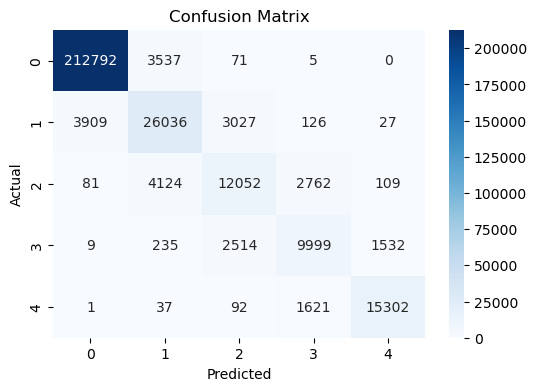


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    216405
           1       0.77      0.79      0.78     33125
           2       0.68      0.63      0.65     19128
           3       0.69      0.70      0.69     14289
           4       0.90      0.90      0.90     17053

    accuracy                           0.92    300000
   macro avg       0.80      0.80      0.80    300000
weighted avg       0.92      0.92      0.92    300000

===
busyness_level_5
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032686 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM

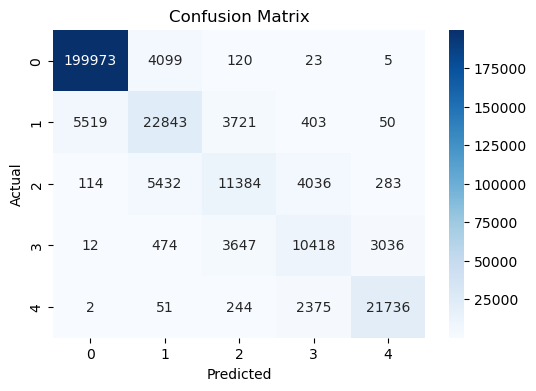


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98    204220
           1       0.69      0.70      0.70     32536
           2       0.60      0.54      0.56     21249
           3       0.60      0.59      0.60     17587
           4       0.87      0.89      0.88     24408

    accuracy                           0.89    300000
   macro avg       0.75      0.74      0.74    300000
weighted avg       0.89      0.89      0.89    300000



In [25]:
for col in busyness_percentile_cols:
    print("===")
    print(col)
    y_lgbm = new_buffer_df[col]
    y_lgbm = y_lgbm.astype(int) - 1
    
    predict_sample_dataset(model=lgbm_model,
                       input_X=X_lgbm,
                       input_y=y_lgbm,
                       sample_size=1000000,
                       y_type='categorical',
                       is_lgbm=True, 
                       eval_metric='multi_logloss')

# Compute Busyness percentiles using other methods
Although we previously found that `busyness_zscore_weighted_percentile` consistently outperforms the other methods in `03_final_score_refinement_and_model_evaluation.ipynb`, we will re-evaluate the alternative approaches on the new dataset to ensure the same trend holds. Other methods will also be examined to see if any of them perform better in terms of heatmap spatial patterns and model performance on the sample data with LightGBM. The `weights_4` configuration, which previously demonstrated the best performance, will be applied in this evaluation.

In [26]:
# The code below is copied from 03_final_score_refinement_and_model_evaluation.ipynb.
# To minimize unnecessary changes, the same variable names are used as in 03_final_score_refinement_and_model_evaluation.ipynb
combined_df = new_buffer_df.copy()
weights = weight4_array.copy()

In [27]:
### -----------------------------
### 1. Z-score normalization
### -----------------------------
# Standardize each feature (mean=0, std=1)
scaler = StandardScaler()

# Z-score equal-weight average
combined_df['busyness_zscore_avg'] = combined_df[[f + '_z' for f in traffic_cols]].mean(axis=1)
combined_df['busyness_zscore_avg_percentile'] = norm.cdf(combined_df['busyness_zscore_avg'])

# Z-score weighted average
combined_df['busyness_zscore_weighted'] = np.dot(combined_df[[f + '_z' for f in traffic_cols]].values, weights)
combined_df['busyness_zscore_weighted_percentile'] = norm.cdf(combined_df['busyness_zscore_weighted'])

### -----------------------------
### 2. MinMax normalization
### -----------------------------
# Scale features to [0, 1]
minmax = MinMaxScaler()
combined_df[[f + '_mm' for f in traffic_cols]] = minmax.fit_transform(combined_df[traffic_cols])

# MinMax equal-weight average
combined_df['busyness_minmax_avg'] = combined_df[[f + '_mm' for f in traffic_cols]].mean(axis=1)
combined_df['busyness_minmax_avg_percentile'] = combined_df['busyness_minmax_avg'].rank(pct=True)

# MinMax weighted average
combined_df['busyness_minmax_weighted'] = np.dot(combined_df[[f + '_mm' for f in traffic_cols]].values, weights)
combined_df['busyness_minmax_weighted_percentile'] = combined_df['busyness_minmax_weighted'].rank(pct=True)

### -----------------------------
### 3. PCA-based score
### -----------------------------
# Use the first principal component to summarize features
pca = PCA(n_components=1)
combined_df['busyness_pca'] = pca.fit_transform(combined_df[traffic_cols])[:, 0]
combined_df['busyness_pca_percentile'] = norm.cdf(combined_df['busyness_pca'])

### -----------------------------
### 4. Z-score summed percentile (Z → Sum → Z → CDF)
### -----------------------------
combined_df['busyness_score'] = combined_df[[f + '_z' for f in traffic_cols]].sum(axis=1)
score_scaler = StandardScaler()
combined_df['busyness_zscore'] = score_scaler.fit_transform(combined_df[['busyness_score']])
combined_df['busyness_percentile'] = norm.cdf(combined_df['busyness_zscore'])

### -----------------------------
### 5. Raw (unscaled) values
### -----------------------------
# Raw equal-weight average
combined_df['busyness_raw_avg'] = combined_df[traffic_cols].mean(axis=1)
combined_df['busyness_raw_avg_percentile'] = combined_df['busyness_raw_avg'].rank(pct=True)

# Raw weighted average
combined_df['busyness_raw_weighted'] = np.dot(combined_df[traffic_cols].values, weights)
combined_df['busyness_raw_weighted_percentile'] = combined_df['busyness_raw_weighted'].rank(pct=True)

In [28]:
busyness_percentile_cols = ['busyness_zscore_avg_percentile', 'busyness_zscore_weighted_percentile',
                            'busyness_minmax_avg_percentile', 'busyness_minmax_weighted_percentile',
                            'busyness_pca_percentile', 'busyness_percentile',
                            'busyness_raw_avg_percentile', 'busyness_raw_weighted_percentile']

## Compare on heatmap

**The results are consistent with what we found in `03_final_score_refinement_and_model_evaluation.ipynb`**

---
To evaluate the spatial reasonableness of each busyness score, we make the following assumption:
    
    - At 12:00 PM, during peak lunch hours, city center areas should appear more busy, with a gradual fading of busyness toward the outer regions.
    - At 3:00 AM, the entire city should appear less busy overall.

We compare the heatmaps generated by each of the six scoring methods based on how well they align with this assumption:

- `busyness_zscore_avg_percentile`, `busyness_zscore_weighted_percentile`, `busyness_percentile`: Heatmaps at both noon and 3 AM generally align with expectations.

- `busyness_minmax_avg_percentile`, `busyness_minmax_weighted_percentile`, `busyness_raw_avg_percentile`, `busyness_raw_weighted_percentile`: At noon, almost the entire area is shown as busy. Even at 3 AM, many regions still appear overly busy, which seems less realistic.

- `busyness_pca_percentile`: Noon heatmap shows many regions as extremely busy, lacking a gradual spatial fade. The 3 AM pattern better matches expectations.

In [29]:
for col in busyness_percentile_cols:
    combined_df[f'{col}_level'] = convert_percentile_to_level(combined_df[col])

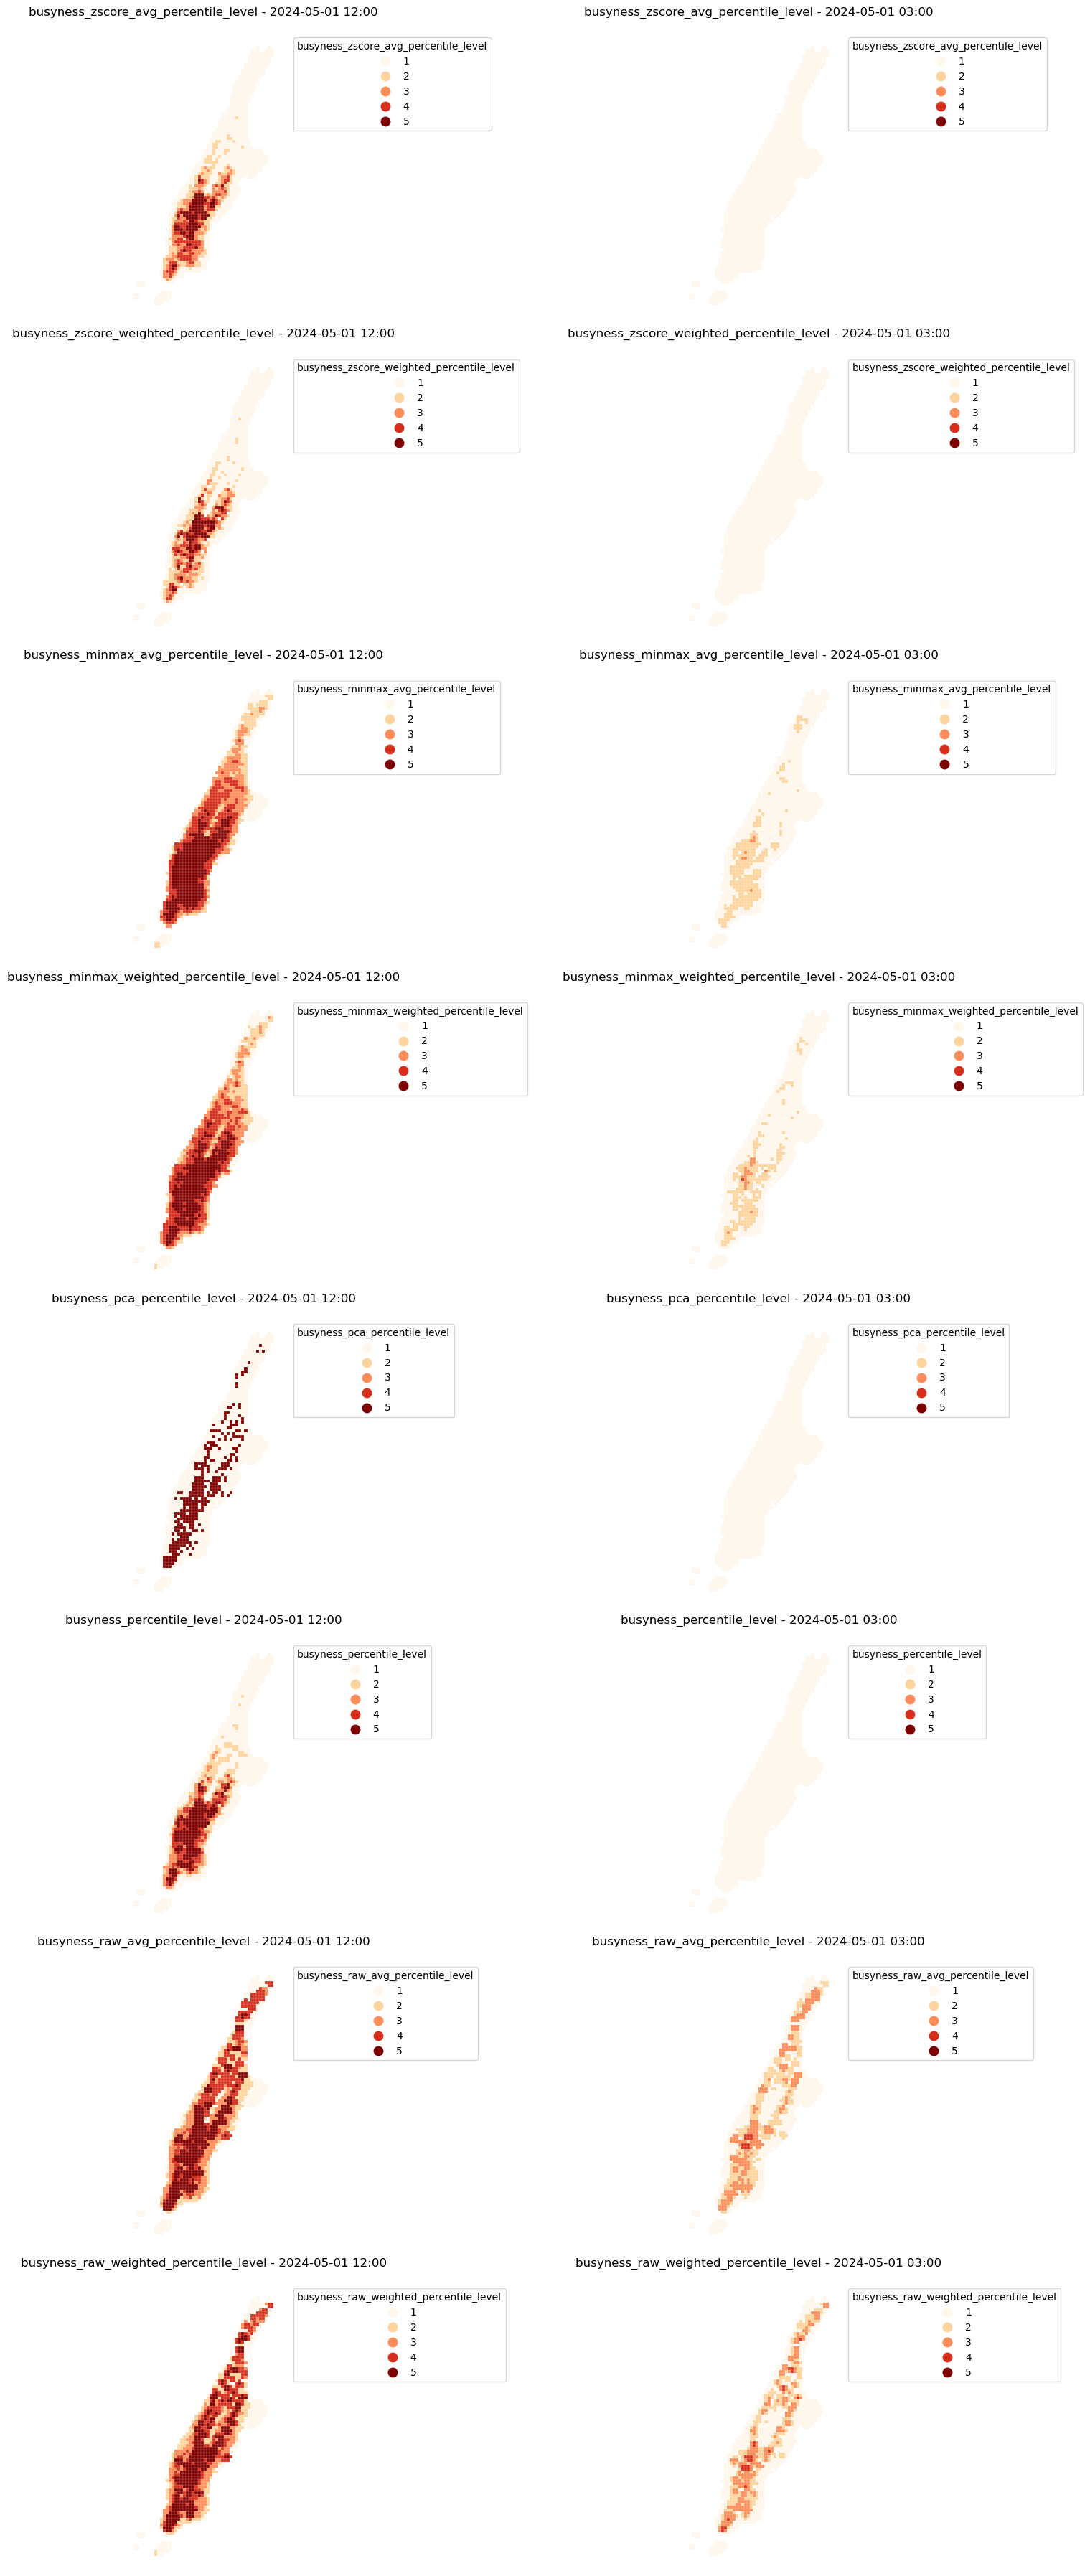

In [30]:
fig, axes = plt.subplots(8, 2, figsize=(18, 36))
i = 0
for col in busyness_percentile_cols:    
    plot_busyness_percentile_map(combined_df, '2024-05-01', 12, f'{col}_level', ax=axes[i, 0])
    plot_busyness_percentile_map(combined_df, '2024-05-01', 3, f'{col}_level', ax=axes[i, 1])
    i += 1

plt.tight_layout()
plt.show()

## Compare model Performance using LightGBM
- Compare LightGBM performance on a sample dataset using different busyness levels derived from various busyness percentile methods.
- Only `busyness_zscore_avg_percentile`, `busyness_zscore_weighted_percentile`, `busyness_percentile` are selected for evaluation on the sample dataset, as they are the only methods that produce reasonable spatial patterns on the heatmap.
    - busyness_zscore_avg_percentile
        - Accuracy       : 0.906
        - Precision Score: 0.782
        - Recall Score   : 0.778
        - F1 Score       : 0.78
    - busyness_zscore_weighted_percentile
        - Accuracy       : 0.92
        - Precision Score: 0.8
        - Recall Score   : 0.797
        - F1 Score       : 0.798
    - busyness_percentile
        - Accuracy       : 0.892
        - Precision Score: 0.758
        - Recall Score   : 0.75
        - F1 Score       : 0.753
- As expected, busyness_zscore_weighted_percentile demonstrates the best performance, which aligns with our previous conclusion.

In [31]:
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    learning_rate=0.1,
    num_leaves=64,
    n_estimators=100,
    random_state=42
)

===
busyness_zscore_avg_percentile
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063480 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2145
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 17
[LightGBM] [Info] Start training from score -0.356422
[LightGBM] [Info] Start training from score -2.167255
[LightGBM] [Info] Start training from score -2.672738
[LightGBM] [Info] Start training from score -2.947269
[LightGBM] [Info] Start training from score -2.752226
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[

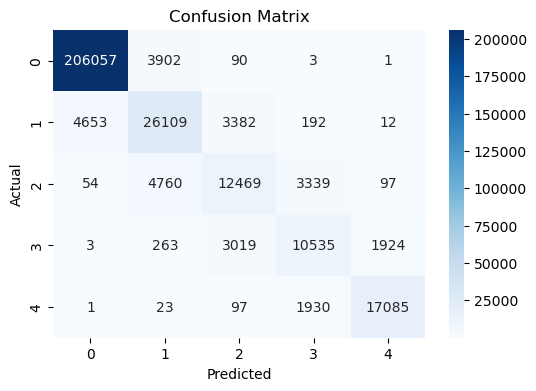


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    210053
           1       0.74      0.76      0.75     34348
           2       0.65      0.60      0.63     20719
           3       0.66      0.67      0.66     15744
           4       0.89      0.89      0.89     19136

    accuracy                           0.91    300000
   macro avg       0.79      0.78      0.78    300000
weighted avg       0.91      0.91      0.91    300000

===
busyness_zscore_weighted_percentile
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050899 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wi

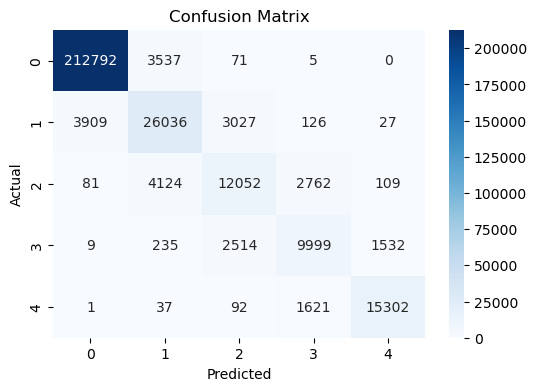


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    216405
           1       0.77      0.79      0.78     33125
           2       0.68      0.63      0.65     19128
           3       0.69      0.70      0.69     14289
           4       0.90      0.90      0.90     17053

    accuracy                           0.92    300000
   macro avg       0.80      0.80      0.80    300000
weighted avg       0.92      0.92      0.92    300000

===
busyness_percentile
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.146551 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2146
[LightGBM] [Info] Number of data poi

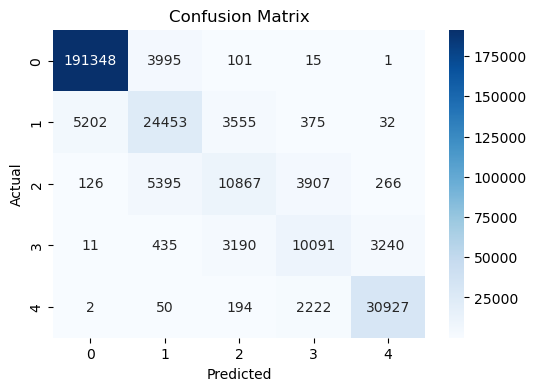


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98    195460
           1       0.71      0.73      0.72     33617
           2       0.61      0.53      0.56     20561
           3       0.61      0.59      0.60     16967
           4       0.90      0.93      0.91     33395

    accuracy                           0.89    300000
   macro avg       0.76      0.75      0.75    300000
weighted avg       0.89      0.89      0.89    300000



In [32]:
selected_percentile_cols = ['busyness_zscore_avg_percentile', 
                            'busyness_zscore_weighted_percentile', 
                            'busyness_percentile']

for col in selected_percentile_cols:
    print("===")
    print(col)
    y_lgbm = combined_df[f'{col}_level']
    y_lgbm = y_lgbm.astype(int) - 1
    
    predict_sample_dataset(model=lgbm_model,
                       input_X=X_lgbm,
                       input_y=y_lgbm,
                       sample_size=1000000,
                       y_type='categorical',
                       is_lgbm=True, 
                       eval_metric='multi_logloss')

# Save current status
- The pkl file is saved in the [shared Google Drive](https://drive.google.com/drive/u/2/folders/19I-XGiqzewbrrrfiun2aVrTdHmH9MbYF)

In [17]:
target_columns = ['month', 'weekofyear', 'dayofweek', 'is_weekend', 'day', 'hour', 'is_holiday', # time
                  'temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm', # weather
                  'grid_id', 'restaurant_count', 'population', # grid info
                  'lat', 'lon', # could be removed
                  'event_count', # event
                  'busyness_level_4', 'busyness_zscore_weighted_percentile_4' # target
                 ]

In [16]:
new_buffer_df[target_columns].to_pickle('new_combined_df.pkl')

In [8]:
new_buffer_df = pd.read_pickle('new_combined_df.pkl')
new_buffer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9986400 entries, 0 to 9986399
Data columns (total 19 columns):
 #   Column                                 Dtype   
---  ------                                 -----   
 0   month                                  category
 1   weekofyear                             category
 2   dayofweek                              category
 3   is_weekend                             category
 4   day                                    category
 5   hour                                   category
 6   is_holiday                             category
 7   temp_c                                 float64 
 8   dew_c                                  float64 
 9   wind_speed_knot                        float64 
 10  precip_mm                              float64 
 11  grid_id                                category
 12  restaurant_count                       float64 
 13  population                             float64 
 14  lat                               